In [398]:
import numpy as np
import tqdm
import torch
from scipy.stats import norm
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F
import pickle

In [399]:
class DiscretePolicyNetwork(nn.Module):
    def __init__(self, state_dim, num_actions=5, hidden_sizes=[20, 20]):
        super(DiscretePolicyNetwork, self).__init__()
        layers = []
        input_size = state_dim
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(input_size, hidden_size))
            layers.append(nn.ReLU())
            input_size = hidden_size
        layers.append(nn.Linear(input_size, num_actions))  # logits over 5 actions
        self.model = nn.Sequential(*layers)

    def forward(self, x):
        logits = self.model(x)  # raw logits
        return torch.softmax(logits, dim=-1) # Probability distribution

def train_discrete_policy(states, one_hot_actions, state_dim, epochs=100, batch_size=16, lr=1e-3):
    # Convert one-hot actions to class indices
    if(np.equal(one_hot_actions, 0).all()):
        raise ValueError("All actions are zero, cannot train policy.")
    action_indices = np.argmax(one_hot_actions, axis=1)

    dataset = TensorDataset(
        torch.tensor(states, dtype=torch.float32),
        torch.tensor(action_indices, dtype=torch.long)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    policy = DiscretePolicyNetwork(state_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    for epoch in range(epochs):

        for batch_states, batch_action_indices in loader:
            # print(batch_states.shape, batch_action_indices.shape)
            logits = policy(batch_states)
            loss = loss_fn(logits, batch_action_indices)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item()}")
    return policy

In [699]:
behavior_trajectories_o = pickle.load(open("mimic_iv_trajectories_behavior.pkl", 'rb')) #behavior policy, original env
target_trajectories_o = pickle.load(open("mimic_iv_trajectories_target.pkl", 'rb')) # target policy, original env
# _trajectories_behavior = pickle.load(open("mimic_iv_behavior_trajectories.pkl", 'rb'))
# _trajectories_target = pickle.load(open("mimic_iv_target_trajectories.pkl", 'rb'))

In [700]:
len(behavior_trajectories_o['states']),len(target_trajectories_o['states'])

(374, 59)

In [623]:
_trajectories_behavior = pickle.load(open("mimic_iv_behavior_trajectories.pkl", 'rb'))
train_b_states = _trajectories_behavior['observations']
mean_b_states = np.mean(train_b_states, axis=0)
std_b_states = np.std(train_b_states, axis=0)

In [402]:
# train_b_states = _trajectories_behavior['observations']
# train_b_actions = _trajectories_behavior['actions']

# train_e_states = _trajectories_target['observations']
# train_e_actions = _trajectories_target['actions']

In [403]:
# reformulate the data
# def normalize_data(data):
#     mean = np.mean(data, axis=0)
#     std = np.std(data, axis=0)
#     return (data - mean) / std

# train_b_states = normalize_data(train_b_states)
# train_e_states = normalize_data(train_e_states)
# mean_b_states = np.mean(train_b_states, axis=0)
# std_b_states = np.std(train_b_states, axis=0)

In [404]:
epochs = 100
batch_size = 64
lr = 1e-4
state_dim = 16

In [405]:
# behavior_policy = train_discrete_policy(train_b_states, train_b_actions, state_dim,
#                                         epochs=epochs, batch_size=batch_size, lr=lr)

In [406]:
# batch_size = 4
# target_policy = train_discrete_policy(train_e_states, train_e_actions, state_dim,
#                                         epochs=epochs, batch_size=batch_size, lr=lr)

In [407]:
# # save the trained policies
# torch.save(behavior_policy.state_dict(), "pi_b.pth")
# torch.save(target_policy.state_dict(), "pi_e.pth")

In [409]:
behavior_policy = DiscretePolicyNetwork(state_dim)
behavior_policy.load_state_dict(torch.load("./saved_model/pi_b.pth"))
behavior_policy.eval()
target_policy = DiscretePolicyNetwork(state_dim)
target_policy.load_state_dict(torch.load("./saved_model/pi_e.pth"))
target_policy.eval()

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_74757/3880959023.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  behavior_policy.load_state_dict(torch.load(".

DiscretePolicyNetwork(
  (model): Sequential(
    (0): Linear(in_features=16, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=5, bias=True)
  )
)

In [701]:
alpha = 0.05
z = norm.ppf(1 - alpha / 2)
ACTION_TO_IDX = {0: 0, 10: 1, 20: 2, 30: 3, 40: 4}

In [702]:
true_b_ep_returns = behavior_trajectories_o['reward_sum']
true_b_states = behavior_trajectories_o['states']
true_b_actions = behavior_trajectories_o['actions']
true_b_rewards = behavior_trajectories_o['rewards']

In [703]:
len(true_b_ep_returns), len(true_b_states), len(true_b_actions), len(true_b_rewards)

(374, 374, 374, 374)

In [704]:
def calculate_ips_product(t_t, t_a, t_r, target_policy, behavior_policy, wis=False, pdis=False, clipping=False):
    # T_t is the states
    if wis: # This works sometimes but produces a biased estimate
        log_probs_target = []
        log_probs_behavior = []
        for i in range(len(t_a)): # All of the actions in the trajectory
            rho_e = np.log(target_policy[t_a[i]])
            rho_b = np.log(behavior_policy[t_a[i]])
            log_probs_target.append(rho_e)
            log_probs_behavior.append(rho_b)

        log_rho_traj = np.asarray(log_probs_target) - np.asarray(log_probs_behavior)
        # return np.exp(np.sum(log_rho_traj) - np.max(log_rho_traj)) # Re-normalizing by the maximum
        return np.sum(log_rho_traj)
    elif clipping:
        log_rhos = []
        for i in range(len(t_a)):
            action = int(np.clip((t_a[i]) // 10 * 10, 0, 40))
            action_idx = ACTION_TO_IDX[action]
            rho_e = np.log(target_policy[action_idx])
            rho_b = np.log(behavior_policy[action_idx])
            log_rho = rho_e - rho_b
            log_rhos.append(log_rho)
        total_log_rho = np.sum(log_rhos)
        clipped_log_rho = np.clip(total_log_rho, a_min=-0.5, a_max=0.5) # You basically lose all signal and just get the clipped values
        return np.exp(clipped_log_rho)
    elif pdis:
        cumulative_log_rhos = []
        cumulative_log_rho = 0.0

        for t in range(len(t_a)):
            action = int(np.clip((t_a[t]) // 10 * 10, 0, 40))
            action_idx = ACTION_TO_IDX[action]
            log_rho_e = np.log(target_policy(torch.Tensor(t_t[t]))[action_idx].detach().numpy().item())
            log_rho_b = np.log(behavior_policy(torch.Tensor(t_t[t]))[action_idx].detach().numpy().item())
            cumulative_log_rho += (log_rho_e - log_rho_b)
            cumulative_log_rhos.append(cumulative_log_rho)

        pdis_estimate = 0.0
        for t in range(len(t_a)):
            weight = np.exp(cumulative_log_rhos[t])
            pdis_estimate += weight * t_r[t]
        return pdis_estimate
    
    else:
        probs_target = []
        probs_behavior = []
        for i in range(len(t_a)):  # All of the actions in the trajectory
            action = int(np.clip((t_a[i]) // 10 * 10, 0, 40))
            action_idx = ACTION_TO_IDX[action]
            rho_e = target_policy(torch.Tensor(t_t[i]))[action_idx].detach().numpy().item()
            rho_b = behavior_policy(torch.Tensor(t_t[i]))[action_idx].detach().numpy().item()
            probs_target.append(rho_e)
            probs_behavior.append(rho_b)

        rho_traj = np.prod(np.asarray(probs_target))/ np.prod(np.asarray(probs_behavior))
        return rho_traj

In [716]:
# IS CLT
V_IS = np.zeros(len(true_b_actions))
for i in range(len(true_b_actions)):
    weight = calculate_ips_product(true_b_states[i], true_b_actions[i], true_b_rewards[i], target_policy, behavior_policy)
    V_IS[i] = weight * true_b_ep_returns[i]
    # print(weight)
V_IS_mean = np.mean(V_IS)
V_IS_var = np.var(V_IS)
V_IS_lb = V_IS_mean - z * np.sqrt(V_IS_var / len(V_IS))
V_IS_ub = V_IS_mean + z * np.sqrt(V_IS_var / len(V_IS))
print("IS CLT: \hat{v}(\pi_e): " + str(V_IS_mean) + " Interval: (" + str(V_IS_lb) + ", " + str(V_IS_ub) + ")")


IS CLT: \hat{v}(\pi_e): 1.6951920500176794 Interval: (0.8812585469249729, 2.509125553110386)


In [445]:
# IS Bootstrap
bootstrap_samples = 100
V_IS_bootstrap = np.zeros(bootstrap_samples)
for i in tqdm.tqdm(range(bootstrap_samples)):
    bootstrap_indices = np.random.choice(len(true_b_actions), size=len(true_b_actions), replace=True)
    V_IS_bootstrap[i] = np.mean(V_IS[bootstrap_indices])

V_IS_bootstrap_mean = np.mean(V_IS_bootstrap)
V_IS_bootstrap_alpha = np.quantile(V_IS_bootstrap, alpha/2)
V_IS_bootstrap_1_alpha = np.quantile(V_IS_bootstrap, 1-alpha/2)
print("IS Bootstrap: \hat{v}(\pi_e): " + str(V_IS_bootstrap_mean) + " Interval: (" + str(V_IS_bootstrap_alpha) + ", " + str(V_IS_bootstrap_1_alpha) + ")")

100%|██████████| 100/100 [00:00<00:00, 27419.13it/s]

IS Bootstrap: \hat{v}(\pi_e): 1.7029350933220815 Interval: (1.0155166462450296, 2.476152795965679)


In [446]:
# DR (CLT)

# train a DQN using the batch data
class DQN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(DQN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim) 
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, output_dim)

    def forward(self, s, a):
        x = torch.cat((s, a), dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

state_dim = 16
action_dim = 5
    
Q = DQN(input_dim=state_dim + action_dim, hidden_dim=16, output_dim=1)

In [470]:
# create train and cal dataset (1:1)
true_b_states_train = true_b_states[:int(len(true_b_states) * 0.5)]
true_b_actions_train = true_b_actions[:int(len(true_b_states) * 0.5)]
true_b_rewards_train = true_b_rewards[:int(len(true_b_states) * 0.5)]
true_b_ep_returns_train = true_b_ep_returns[:int(len(true_b_states) * 0.5)]
true_b_states_cal = true_b_states[int(len(true_b_states) * 0.5):]
true_b_actions_cal = true_b_actions[int(len(true_b_states) * 0.5):]
true_b_rewards_cal = true_b_rewards[int(len(true_b_states) * 0.5):]
true_b_ep_returns_cal = true_b_ep_returns[int(len(true_b_states) * 0.5):]

In [473]:
# convert to batch data
def convert_to_batch_data(trajectories, actions, rewards):
    batch_data = []
    for traj, action, reward in zip(trajectories, actions, rewards):
        for t in range(len(traj)-1):
            s = traj[t]
            a = action[t]
            a = int(np.clip((a) // 10 * 10, 0, 40))
            r = reward[t]
            s_next = traj[t+1]
            batch_data.append((s, a, r, s_next))
    return batch_data
batch_data = convert_to_batch_data(true_b_states_train, true_b_actions_train, true_b_rewards_train)

In [474]:
len(batch_data)

2830

In [475]:
optimizer = optim.Adam(Q.parameters(), lr=0.001)
criterion = nn.MSELoss()
num_epochs = 100
batch_size = 64
for epoch in range(num_epochs):
    np.random.shuffle(batch_data)
    for i in range(0, len(batch_data), batch_size):
        batch = batch_data[i:i + batch_size]
        s = torch.tensor([b[0] for b in batch], dtype=torch.float32)
        a = torch.tensor([b[1] for b in batch], dtype=torch.float32)
        r = torch.tensor([b[2] for b in batch], dtype=torch.float32)
        s1 = torch.tensor([b[3] for b in batch], dtype=torch.float32)
        # print(s.shape, a.shape, r.shape, s1.shape)

        # one-hot encode the actions
        a_one_hot = torch.zeros(a.shape[0], 5)
        for j in range(a.shape[0]):
            action_idx = ACTION_TO_IDX[a[j].item()]
            a_one_hot[j, action_idx] = 1
        
        q_value = Q(s, a_one_hot)
        
        V_pi_e = 0

        pi_e = target_policy(s1)
        for a in range(5):
            # get the action probability
            prob = target_policy(s1)[:, a]
            a_one_hot = torch.zeros(s1.shape[0], 5)
            a_one_hot[:, a] = 1
            V_pi_e += prob * Q(s1, a_one_hot)
        
        target_q_value = r.unsqueeze(1) + 1 * V_pi_e
        loss = criterion(q_value, target_q_value)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 1 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}')


/opt/anaconda3/envs/sepsis/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([64, 64])) that is different to the input size (torch.Size([64, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/sepsis/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([14, 14])) that is different to the input size (torch.Size([14, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [0/100], Loss: 0.0000
Epoch [1/100], Loss: 0.0000
Epoch [2/100], Loss: 0.0000
Epoch [3/100], Loss: 0.0000
Epoch [4/100], Loss: 0.0000
Epoch [5/100], Loss: 0.0000
Epoch [6/100], Loss: 0.0000
Epoch [7/100], Loss: 0.0000
Epoch [8/100], Loss: 0.0000
Epoch [9/100], Loss: 0.0000
Epoch [10/100], Loss: 0.0000
Epoch [11/100], Loss: 0.0000
Epoch [12/100], Loss: 0.0000
Epoch [13/100], Loss: 0.0000
Epoch [14/100], Loss: 0.0000
Epoch [15/100], Loss: 0.0000
Epoch [16/100], Loss: 0.0000
Epoch [17/100], Loss: 0.0000
Epoch [18/100], Loss: 0.0000
Epoch [19/100], Loss: 0.0000
Epoch [20/100], Loss: 0.0000
Epoch [21/100], Loss: 0.0000
Epoch [22/100], Loss: 0.0000
Epoch [23/100], Loss: 0.0000
Epoch [24/100], Loss: 0.0000
Epoch [25/100], Loss: 0.0000
Epoch [26/100], Loss: 0.0000
Epoch [27/100], Loss: 0.0000
Epoch [28/100], Loss: 0.0000
Epoch [29/100], Loss: 0.0000
Epoch [30/100], Loss: 0.0000
Epoch [31/100], Loss: 0.0000
Epoch [32/100], Loss: 0.0000
Epoch [33/100], Loss: 0.0000
Epoch [34/100], Loss: 0.

In [478]:
V_DR_step = np.zeros(len(true_b_actions_cal))
for i in range(len(true_b_actions_cal)):
    v = 0
    for t in range(len(true_b_actions_cal[i])):
        s = true_b_states_cal[i][t]
        a_idx = true_b_actions_cal[i][t]
        r = true_b_rewards_cal[i][t]
        a_idx = int(np.clip((a_idx) // 10 * 10, 0, 40))
        a_idx = ACTION_TO_IDX[a_idx]
        
        s = torch.tensor(s, dtype=torch.float32).reshape(1, -1)
        a_one_hot = torch.zeros(1, 5)
        a_one_hot[0, a_idx] = 1
        tensor_a = torch.tensor(a_one_hot, dtype=torch.float32)
        Q_s_a = Q(s, tensor_a).detach().numpy()
        Q_s_a = float(Q_s_a)

        V_s = 0
        for a1 in range(5):
            tensor_a1 = torch.zeros(1, 5)
            tensor_a1[0, a1] = 1
            V_s_a1 = Q(s, tensor_a1).detach().numpy()
            V_s += target_policy(s)[0][a1] * float(V_s_a1)
        
        w = target_policy(torch.tensor(s, dtype=torch.float32))[0][a_idx].detach().numpy() / behavior_policy(torch.tensor(s, dtype=torch.float32))[0][a_idx].detach().numpy()
        v = V_s + w * (r + 1 * v - Q_s_a)
    V_DR_step[i] = v

# calculate the average of V_DR
V_DR_step_mean = np.mean(V_DR_step)
V_DR_step_var = np.var(V_DR_step)
V_DR_step_lb = V_DR_step_mean - z * np.sqrt(V_DR_step_var / len(V_DR_step))
V_DR_step_ub = V_DR_step_mean + z * np.sqrt(V_DR_step_var / len(V_DR_step))
print('V_DR:', V_DR_step_mean)
print('V_DR_LB:', V_DR_step_lb)
print('V_DR_UB:', V_DR_step_ub)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_74757/3937719674.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor_a = torch.tensor(a_one_hot, dtype=torch.float32)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_74757/3937719674.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Q_s_a = float(Q_s_a)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_74757/3937719674.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_s += target_policy(s)[0][a1]

V_DR: 1.0497328379256203
V_DR_LB: 0.2774073658886196
V_DR_UB: 1.822058309962621


In [510]:
behavior_trajectories_gen_1 = pickle.load(open('./saved_trajectories/learned_b_1.pkl', 'rb'))
behavior_trajectories_gen_2 = pickle.load(open('./saved_trajectories/learned_b_2.pkl', 'rb'))
behavior_trajectories_gen_3 = pickle.load(open('./saved_trajectories/learned_b_3.pkl', 'rb'))
behavior_trajectories_gen_4 = pickle.load(open('./saved_trajectories/learned_b_4.pkl', 'rb'))
behavior_trajectories_gen_5 = pickle.load(open('./saved_trajectories/learned_b_5.pkl', 'rb'))
behavior_trajectories_gen_6 = pickle.load(open('./saved_trajectories/learned_b_6.pkl', 'rb'))
behavior_trajectories_gen_7 = pickle.load(open('./saved_trajectories/learned_b_7.pkl', 'rb'))
behavior_trajectories_gen_8 = pickle.load(open('./saved_trajectories/learned_b_8.pkl', 'rb'))
behavior_trajectories_gen_9 = pickle.load(open('./saved_trajectories/learned_b_9.pkl', 'rb'))
behavior_trajectories_gen_10 = pickle.load(open('./saved_trajectories/learned_b_10.pkl', 'rb'))

In [514]:
# merge the trajectories
behavior_trajectories_gen = {}
behavior_trajectories_gen['states'] = np.concatenate((behavior_trajectories_gen_1['states'], behavior_trajectories_gen_2['states'], behavior_trajectories_gen_3['states'], behavior_trajectories_gen_4['states'], behavior_trajectories_gen_5['states'], behavior_trajectories_gen_6['states'], behavior_trajectories_gen_7['states'], behavior_trajectories_gen_8['states'], behavior_trajectories_gen_9['states'], behavior_trajectories_gen_10['states']), axis=0)
behavior_trajectories_gen['actions'] = np.concatenate((behavior_trajectories_gen_1['actions'], behavior_trajectories_gen_2['actions'], behavior_trajectories_gen_3['actions'], behavior_trajectories_gen_4['actions'], behavior_trajectories_gen_5['actions'], behavior_trajectories_gen_6['actions'], behavior_trajectories_gen_7['actions'], behavior_trajectories_gen_8['actions'], behavior_trajectories_gen_9['actions'], behavior_trajectories_gen_10['actions']), axis=0)
behavior_trajectories_gen['rewards'] = np.concatenate((behavior_trajectories_gen_1['rewards'], behavior_trajectories_gen_2['rewards'], behavior_trajectories_gen_3['rewards'], behavior_trajectories_gen_4['rewards'], behavior_trajectories_gen_5['rewards'], behavior_trajectories_gen_6['rewards'], behavior_trajectories_gen_7['rewards'], behavior_trajectories_gen_8['rewards'], behavior_trajectories_gen_9['rewards'], behavior_trajectories_gen_10['rewards']), axis=0)
behavior_trajectories_gen['ep_returns'] = np.concatenate((behavior_trajectories_gen_1['ep_returns'], behavior_trajectories_gen_2['ep_returns'], behavior_trajectories_gen_3['ep_returns'], behavior_trajectories_gen_4['ep_returns'], behavior_trajectories_gen_5['ep_returns'], behavior_trajectories_gen_6['ep_returns'], behavior_trajectories_gen_7['ep_returns'], behavior_trajectories_gen_8['ep_returns'], behavior_trajectories_gen_9['ep_returns'], behavior_trajectories_gen_10['ep_returns']), axis=0)

In [515]:
aug_b_states = behavior_trajectories_gen['states']
aug_b_actions = behavior_trajectories_gen['actions']
aug_b_rewards = behavior_trajectories_gen['rewards']
aug_b_ep_returns = behavior_trajectories_gen['ep_returns']

actions = []
for i in range(len(aug_b_actions)):
    actions.append(np.argmax(aug_b_actions[i], axis=1))
aug_b_actions = np.array(actions)

In [517]:
# merge the true and augmented data
whole_b_states = []
whole_b_actions = []
whole_b_rewards = []
whole_b_ep_returns = []

for i in range(len(true_b_states)):
    whole_b_states.append(np.array(true_b_states[i]))
    whole_b_actions.append(np.array(true_b_actions[i]))
    whole_b_rewards.append(np.array(true_b_rewards[i]))
    whole_b_ep_returns.append(np.array(true_b_ep_returns[i]))
for i in range(len(aug_b_states)):
    whole_b_states.append(np.array(aug_b_states[i]))
    whole_b_actions.append(np.array(aug_b_actions[i]))
    whole_b_rewards.append(np.array(aug_b_rewards[i]))
    whole_b_ep_returns.append(np.array(aug_b_ep_returns[i]))

# # shuffle the data
# indices = np.arange(len(whole_b_states))
# np.random.shuffle(indices)
# whole_b_states = whole_b_states[indices]
# whole_b_actions = whole_b_actions[indices]
# whole_b_rewards = whole_b_rewards[indices]
# whole_b_ep_returns = whole_b_ep_returns[indices]

In [518]:
 # Aug IS (CLT)
aug_V_IS = np.zeros(len(whole_b_actions))
for i in range(len(whole_b_actions)):
    rho = calculate_ips_product(whole_b_states[i], whole_b_actions[i], whole_b_rewards[i], target_policy, behavior_policy)
    aug_V_IS[i] = rho * whole_b_ep_returns[i]
aug_V_IS_mean = np.mean(aug_V_IS)
aug_V_IS_var = np.var(aug_V_IS)
aug_V_IS_lb = aug_V_IS_mean - z * np.sqrt(aug_V_IS_var / len(aug_V_IS))
aug_V_IS_ub = aug_V_IS_mean + z * np.sqrt(aug_V_IS_var / len(aug_V_IS))
print("AugIS CLT: \hat{v}(\pi_e): " + str(aug_V_IS_mean) + " Interval: (" + str(aug_V_IS_lb) + ", " + str(aug_V_IS_ub) + ")")

AugIS CLT: \hat{v}(\pi_e): 0.9817795285060746 Interval: (0.7590090791614805, 1.2045499778506688)


In [519]:
# Aug IS (Bootstrap)
bootstrap_samples = 100
aug_V_IS_bootstrap = np.zeros(bootstrap_samples)
for i in range(bootstrap_samples):
    bootstrap_indices = np.random.choice(len(aug_V_IS), size=len(aug_V_IS), replace=True)
    aug_V_IS_bootstrap[i] = np.mean(aug_V_IS[bootstrap_indices])
aug_V_IS_bootstrap_mean = np.mean(aug_V_IS_bootstrap)
aug_V_IS_bootstrap_alpha = np.quantile(aug_V_IS_bootstrap, alpha/2)
aug_V_IS_bootstrap_1_alpha = np.quantile(aug_V_IS_bootstrap, 1-alpha/2)
print("AugIS Bootstrap: \hat{v}(\pi_e): " + str(aug_V_IS_bootstrap_mean) + " Interval: (" + str(aug_V_IS_bootstrap_alpha) + ", " + str(aug_V_IS_bootstrap_1_alpha) + ")")

AugIS Bootstrap: \hat{v}(\pi_e): 0.9902482281073172 Interval: (0.781531189137009, 1.263869827877915)


In [520]:
# create train and cal dataset (1:1)
whole_b_states_train = whole_b_states[:int(len(whole_b_states) * 0.5)]
whole_b_actions_train = whole_b_actions[:int(len(whole_b_states) * 0.5)]
whole_b_rewards_train = whole_b_rewards[:int(len(whole_b_states) * 0.5)]
whole_b_ep_returns_train = whole_b_ep_returns[:int(len(whole_b_states) * 0.5)]
whole_b_states_cal = whole_b_states[int(len(whole_b_states) * 0.5):]
whole_b_actions_cal = whole_b_actions[int(len(whole_b_states) * 0.5):]
whole_b_rewards_cal = whole_b_rewards[int(len(whole_b_states) * 0.5):]
whole_b_ep_returns_cal = whole_b_ep_returns[int(len(whole_b_states) * 0.5):]

In [521]:
# convert to batch data
def convert_to_batch_data(trajectories, actions, rewards):
    batch_data = []
    for traj, action, reward in zip(trajectories, actions, rewards):
        for t in range(len(traj)-1):
            s = traj[t]
            a = action[t]
            a = int(np.clip((a) // 10 * 10, 0, 40))
            r = reward[t]
            s_next = traj[t+1]
            batch_data.append((s, a, r, s_next))
    return batch_data
aug_batch_data = convert_to_batch_data(whole_b_states_train, whole_b_actions_train, whole_b_rewards_train)

In [522]:
aug_Q = DQN(input_dim=state_dim + action_dim, hidden_dim=16, output_dim=1)

In [523]:
# Aug DR (CLT)
optimizer = optim.Adam(aug_Q.parameters(), lr=0.001)
criterion = nn.MSELoss()
num_epochs = 100
batch_size = 256
for epoch in range(num_epochs):
    np.random.shuffle(aug_batch_data)
    for i in range(0, len(aug_batch_data), batch_size):
        batch = aug_batch_data[i:i + batch_size]
        s = torch.tensor([b[0] for b in batch], dtype=torch.float32)
        a = torch.tensor([b[1] for b in batch], dtype=torch.float32)
        r = torch.tensor([b[2] for b in batch], dtype=torch.float32)
        s1 = torch.tensor([b[3] for b in batch], dtype=torch.float32)
        # print(s.shape, a.shape, r.shape, s1.shape)

        # one-hot encode the actions
        a_one_hot = torch.zeros(a.shape[0], 5)
        for j in range(a.shape[0]):
            action_idx = ACTION_TO_IDX[a[j].item()]
            a_one_hot[j, action_idx] = 1
        
        q_value = aug_Q(s, a_one_hot)
        
        V_pi_e = 0

        pi_e = target_policy(s1)
        for a in range(5):
            # get the action probability
            prob = target_policy(s1)[:, a]
            a_one_hot = torch.zeros(s1.shape[0], 5)
            a_one_hot[:, a] = 1
            V_pi_e += prob * aug_Q(s1, a_one_hot)
        
        target_q_value = r.unsqueeze(1) + 1 * V_pi_e
        loss = criterion(q_value, target_q_value)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch % 1 == 0:
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}')


/opt/anaconda3/envs/sepsis/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([256, 256])) that is different to the input size (torch.Size([256, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
/opt/anaconda3/envs/sepsis/lib/python3.9/site-packages/torch/nn/modules/loss.py:608: UserWarning: Using a target size (torch.Size([91, 91])) that is different to the input size (torch.Size([91, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch [0/100], Loss: 0.3650
Epoch [1/100], Loss: 0.1492
Epoch [2/100], Loss: 0.0974
Epoch [3/100], Loss: 0.0938
Epoch [4/100], Loss: 0.0738
Epoch [5/100], Loss: 0.0487
Epoch [6/100], Loss: 0.0361
Epoch [7/100], Loss: 0.0364
Epoch [8/100], Loss: 0.0364
Epoch [9/100], Loss: 0.0131
Epoch [10/100], Loss: 0.0254
Epoch [11/100], Loss: 0.0179
Epoch [12/100], Loss: 0.0145
Epoch [13/100], Loss: 0.0197
Epoch [14/100], Loss: 0.0138
Epoch [15/100], Loss: 0.0123
Epoch [16/100], Loss: 0.0295
Epoch [17/100], Loss: 0.0145
Epoch [18/100], Loss: 0.0307
Epoch [19/100], Loss: 0.0104
Epoch [20/100], Loss: 0.1195
Epoch [21/100], Loss: 0.0113
Epoch [22/100], Loss: 0.0038
Epoch [23/100], Loss: 0.0092
Epoch [24/100], Loss: 0.0051
Epoch [25/100], Loss: 0.0046
Epoch [26/100], Loss: 0.0082
Epoch [27/100], Loss: 0.0121
Epoch [28/100], Loss: 0.0077
Epoch [29/100], Loss: 0.0056
Epoch [30/100], Loss: 0.0046
Epoch [31/100], Loss: 0.0063
Epoch [32/100], Loss: 0.0075
Epoch [33/100], Loss: 0.0068
Epoch [34/100], Loss: 0.

In [ ]:
aug_V_DR_step = np.zeros(len(whole_b_actions_cal))
for i in range(len(whole_b_actions_cal)):
    v = 0
    for t in range(len(whole_b_actions_cal[i])):
        s = whole_b_states_cal[i][t]
        a_idx = whole_b_actions_cal[i][t]
        r = whole_b_rewards_cal[i][t]
        a_idx = int(np.clip((a_idx) // 10 * 10, 0, 40))
        a_idx = ACTION_TO_IDX[a_idx]
        
        s = torch.tensor(s, dtype=torch.float32).reshape(1, -1)
        a_one_hot = torch.zeros(1, 5)
        a_one_hot[0, a_idx] = 1
        tensor_a = torch.tensor(a_one_hot, dtype=torch.float32)
        Q_s_a = aug_Q(s, tensor_a).detach().numpy()
        Q_s_a = float(Q_s_a)

        V_s = 0
        for a1 in range(5):
            tensor_a1 = torch.zeros(1, 5)
            tensor_a1[0, a1] = 1
            V_s_a1 = aug_Q(s, tensor_a1).detach().numpy()
            V_s += target_policy(s)[0][a1] * float(V_s_a1)
        
        w = target_policy(torch.tensor(s, dtype=torch.float32))[0][a_idx].detach().numpy() / behavior_policy(torch.tensor(s, dtype=torch.float32))[0][a_idx].detach().numpy()
        v = V_s + w * (r + 1 * v - Q_s_a)
    aug_V_DR_step[i] = v

# calculate the average of V_DR
aug_V_DR_step_mean = np.mean(aug_V_DR_step)
aug_V_DR_step_var = np.var(aug_V_DR_step)
aug_V_DR_step_lb = aug_V_DR_step_mean - z * np.sqrt(aug_V_DR_step_var / len(aug_V_DR_step))
aug_V_DR_step_ub = aug_V_DR_step_mean + z * np.sqrt(aug_V_DR_step_var / len(aug_V_DR_step))
print('Aug_V_DR:', aug_V_DR_step_mean)
print('Aug_V_DR_LB:', aug_V_DR_step_lb)
print('Aug_V_DR_UB:', aug_V_DR_step_ub)

/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_74757/4261511565.py:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tensor_a = torch.tensor(a_one_hot, dtype=torch.float32)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_74757/4261511565.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  Q_s_a = float(Q_s_a)
/var/folders/yc/lqgm3q450pb2g1j5qwbhhqsm0000gn/T/ipykernel_74757/4261511565.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  V_s += target_policy(s)[0][a1]

AugV_DR: 0.7225819288209363
AugV_DR_LB: 0.7179274281787054
AugV_DR_UB: 0.7272364294631672


In [707]:
first_term_trajs = pickle.load(open("./saved_trajectories/first_term_dr_ppi.pkl", 'rb')) # target policy, learned dynamics
first_term_mean = np.mean(first_term_trajs['ep_returns'])
var_f = np.var(first_term_trajs['ep_returns'])

In [712]:
dr_trajs_1 = pickle.load(open("./saved_trajectories/matching_dr_ppi_1.pkl", 'rb'))
dr_trajs_2 = pickle.load(open("./saved_trajectories/matching_dr_ppi_2.pkl", 'rb'))
dr_trajs_3 = pickle.load(open("./saved_trajectories/matching_dr_ppi_3.pkl", 'rb'))
dr_trajs_4 = pickle.load(open("./saved_trajectories/matching_dr_ppi_4.pkl", 'rb'))

dr_trajs = {}
for i in range(len(true_b_actions)):
    dr_trajs[i] = {}
    dr_trajs[i]['ep_returns'] = np.concatenate((dr_trajs_1[i]['ep_returns'], dr_trajs_2[i]['ep_returns'], dr_trajs_3[i]['ep_returns'], dr_trajs_4[i]['ep_returns']), axis=0)
    dr_trajs[i]['states'] = np.concatenate((dr_trajs_1[i]['states'], dr_trajs_2[i]['states'], dr_trajs_3[i]['states'], dr_trajs_4[i]['states']), axis=0)
    dr_trajs[i]['actions'] = np.concatenate((dr_trajs_1[i]['actions'], dr_trajs_2[i]['actions'], dr_trajs_3[i]['actions'], dr_trajs_4[i]['actions']), axis=0)
    dr_trajs[i]['rewards'] = np.concatenate((dr_trajs_1[i]['rewards'], dr_trajs_2[i]['rewards'], dr_trajs_3[i]['rewards'], dr_trajs_4[i]['rewards']), axis=0)

In [713]:
# DR-PPI

# IS
weights = []
for i in range(len(true_b_actions)):
    weight = calculate_ips_product(true_b_states[i], true_b_actions[i], true_b_rewards[i], target_policy, behavior_policy)
    weights.append(weight)

second_term_all_IS = []
for i in range(len(weights)):
    second_term_all_IS.append(weights[i] * true_b_ep_returns[i] - np.mean(dr_trajs[i]['ep_returns'])) 
var_b_IS = np.var(second_term_all_IS)  # Variance of the second term
var_ppi_IS = var_f / len(first_term_trajs['ep_returns']) + var_b_IS / len(second_term_all_IS)
mean_ppi_IS = first_term_mean + np.mean(second_term_all_IS)
print("V_DRPPI_IS_mean:", mean_ppi_IS)
print("DR-PPI-IS: Interval: (" + str(mean_ppi_IS - z * np.sqrt(var_ppi_IS)) + ", " + str(mean_ppi_IS + z * np.sqrt(var_ppi_IS)) + ")")

# WIS
normalized_weights = []
for i in range(len(weights)):
    normalized_weights.append(weights[i] / np.sum(weights))

second_term_all_WIS = []
for i in range(len(weights)):
    second_term_all_WIS.append(normalized_weights[i] * true_b_ep_returns[i] - np.mean(dr_trajs[i]['ep_returns'])/len(weights))
var_b_WIS = np.var(second_term_all_WIS)  # Variance of the second term
var_ppi_WIS = var_f / len(first_term_trajs['ep_returns']) + var_b_WIS * len(second_term_all_WIS)
mean_ppi_WIS = first_term_mean + np.sum(second_term_all_WIS)
print("V_DRPPI_WIS_mean:", mean_ppi_WIS)
print("DR-PPI-WIS: Interval: (" + str(mean_ppi_WIS - z * np.sqrt(var_ppi_WIS)) + ", " + str(mean_ppi_WIS + z * np.sqrt(var_ppi_WIS)) + ")")


# PDIS
second_term_all_PDIS = []
for _, i in enumerate(tqdm.tqdm(range(len(true_b_actions)))):
    reweighted_value = calculate_ips_product(true_b_states[i], true_b_actions[i], true_b_rewards[i], target_policy, behavior_policy, pdis=True)
    m_term = np.mean(dr_trajs[i]['ep_returns'])
    second_term_all_PDIS.append(reweighted_value - m_term) # If pdis, rho includes the return of the trajectory already

var_b_PDIS = np.var(second_term_all_PDIS)  # Variance of the second term
var_ppi_PDIS = var_f / len(first_term_trajs['ep_returns']) + var_b_PDIS / len(second_term_all_PDIS)
mean_ppi_PDIS = first_term_mean + np.mean(second_term_all_PDIS)
print("V_DRPPI_PDIS_mean:", mean_ppi_PDIS)
print("DR-PPI-PDIS: Interval: (" + str(mean_ppi_PDIS - z * np.sqrt(var_ppi_PDIS)) + ", " + str(mean_ppi_PDIS + z * np.sqrt(var_ppi_PDIS)) + ")")

V_DRPPI_IS_mean: 1.656175370864603
DR-PPI-IS: Interval: (0.8421634205116839, 2.470187321217522)
V_DRPPI_WIS_mean: 0.8731441107348424
DR-PPI-WIS: Interval: (0.4350313089841502, 1.3112569124855347)


100%|██████████| 374/374 [00:00<00:00, 1017.00it/s]

V_DRPPI_PDIS_mean: 1.6561753708646052
DR-PPI-PDIS: Interval: (0.8421634205116844, 2.470187321217526)


In [598]:
def weighted_quantile(values, alpha, sample_weight=None):

    values = np.array(values)
    sample_weight = np.array(sample_weight)

    sorter = np.argsort(values)
    values = values[sorter]
    sample_weight = sample_weight[sorter]

    low_level = 0
    high_level = 0
    low_q = 0
    high_q = 0
    for i in range(len(values)):
        low_level += sample_weight[i]
        if low_level >= alpha / 2:
            low_q = values[i - 1]
            break
    for i in range(len(values)):
        high_level += sample_weight[i]
        if high_level >= 1 - alpha / 2:
            high_q = values[i - 1]
            break
    return (low_q, high_q)

In [581]:
first_term_trajs_s0 = pickle.load(open('./saved_trajectories/first_term_cp_ppi.pkl', 'rb'))  # target policy, learned dynamics
first_term_mean_s0 = np.mean(first_term_trajs_s0['ep_returns'])

In [644]:
cp_trajs_1 = pickle.load(open('./saved_trajectories/matching_cp_ppi_1.pkl', 'rb'))
cp_trajs_2 = pickle.load(open('./saved_trajectories/matching_cp_ppi_2.pkl', 'rb'))

In [675]:
# create the matching trajectories
cp_trajs = {}
for i in range(len(true_b_actions)):
    cp_trajs[i] = {}
    cp_trajs[i]['states'] = [cp_trajs_1[i]['states'][0], cp_trajs_2[i]['states'][0]]
    cp_trajs[i]['actions'] = [cp_trajs_1[i]['actions'][0], cp_trajs_2[i]['actions'][0]]
    cp_trajs[i]['rewards'] = [cp_trajs_1[i]['rewards'][0], cp_trajs_2[i]['rewards'][0]]
    cp_trajs[i]['ep_returns'] = [cp_trajs_1[i]['ep_returns'][0], cp_trajs_2[i]['ep_returns'][0]]

In [676]:
scores = []

for i in range(len(true_b_actions_cal)):
    # Get the trajectories that already match
    matched_trajs = cp_trajs[i+len(true_b_actions_train)]
    for j in range(len(matched_trajs['ep_returns'])):
        return_difference_ij = true_b_ep_returns_cal[i] - matched_trajs['ep_returns'][j]
        scores.append(return_difference_ij)


(array([ 37.,   0.,   0.,  37.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 150.,   0.,   0.,
        150.]),
 array([-0.71281165, -0.70245807, -0.69210449, -0.68175091, -0.67139732,
        -0.66104374, -0.65069016, -0.64033658, -0.629983  , -0.61962941,
        -0.60927583, -0.59892225, -0.58856867, -0.57821509, -0.5678615 ,
        -0.55750792, -0.54715434, -0.53680076, -0.52644717, -0.51609359,
        -0.50574001, -0.49

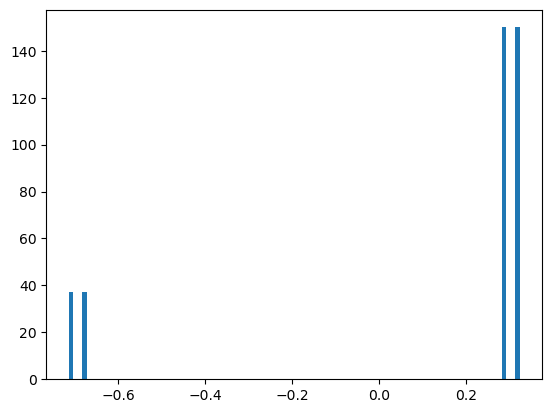

In [677]:
# plot the distribution of scores
import matplotlib.pyplot as plt
plt.hist(scores, bins=100)

In [638]:
# normalize the states
true_b_states_train_normalized = []
for i in range(len(true_b_states_train)):
    for t in range(len(true_b_states_train[i])):
        true_b_states_train[i][t] = (true_b_states_train[i][t] - mean_b_states) / std_b_states
        true_b_states_train_normalized.append(true_b_states_train[i][t])

true_b_states_cal_normalized = []
for i in range(len(true_b_states_cal)):
    for t in range(len(true_b_states_cal[i])):
        true_b_states_cal[i][t] = (true_b_states_cal[i][t] - mean_b_states) / std_b_states
        true_b_states_cal_normalized.append(true_b_states_cal[i][t])

In [679]:
def calculate_cppi_weights(b_gen_t, b_gen_a, b_gen_r, b_t, b_a, b_r, target_policy, behavior_policy):
    probs_target = [] # pi_e(b_gen) * pi_e(b_t)
    probs_behavior = [] # pi_b(b_gen) * pi_b(b_t)
    for i in range(len(b_gen_a)):
        action_gen_idx = ACTION_TO_IDX[np.argmax(b_gen_a[i])]
        rho_e = target_policy(torch.Tensor(b_gen_t[i]))[action_gen_idx].detach().numpy().item() 
        rho_b = behavior_policy(torch.Tensor(b_gen_t[i]))[action_gen_idx].detach().numpy().item()
        probs_target.append(rho_e)
        probs_behavior.append(rho_b)
    for i in range(len(b_a)):
        action_t = int(np.clip((b_a[i]) // 10 * 10, 0, 40))
        action_t_idx = ACTION_TO_IDX[action_t]
        rho_e = target_policy(torch.Tensor(b_t[i]))[action_t_idx].detach().numpy().item()
        rho_b = behavior_policy(torch.Tensor(b_t[i]))[action_t_idx].detach().numpy().item()
        probs_target.append(rho_e)
        probs_behavior.append(rho_b)

    if np.prod(probs_behavior) == 0:
        return 0 # This pair of trajectories is either unlikely or bad --> we don't want to consider this in the correction
    else:
        rho_traj = np.prod(probs_target) / np.prod(probs_behavior)
        return rho_traj

def find_matched_trajectories(return_difference_ij, initial_state):
    normalized_b_o_rs = true_b_states_train_normalized
    b_o_rs = true_b_ep_returns
    b_o_ts = true_b_states
    b_o_as = true_b_actions
    b_o_tr = true_b_rewards
    epsilon_r = 0.01
    epsilon_s = 0.01
    weights = [] # Each element should be a weight
    for i in range(len(true_b_actions_train)):
        # If the initial state matches
        behavior_s0 = normalized_b_o_rs[i][0]
        behavior_return = b_o_rs[i]
        if np.linalg.norm(initial_state - behavior_s0) < epsilon_s: # the first state matches
            matched_trajs = cp_trajs[i]
            for j in range(len(matched_trajs['ep_returns'])):
                diff_proposed_match = behavior_return - matched_trajs['ep_returns'][j]
                if np.abs(return_difference_ij - diff_proposed_match) < epsilon_r:
                    w_cppi = calculate_cppi_weights(matched_trajs['states'][j], matched_trajs['actions'][j], matched_trajs['rewards'][j], b_o_ts[i], b_o_as[i], b_o_tr[i], target_policy, behavior_policy)
                    weights.append(w_cppi)
    return weights

In [680]:
#CP-PPI
weights = []
scores = []

for i in range(len(true_b_actions_cal)):
    # Get the trajectories that already match
    matched_trajs = cp_trajs[i+len(true_b_actions_train)]
    for j in range(len(matched_trajs['ep_returns'])):
        return_difference_ij = true_b_ep_returns_cal[i] - matched_trajs['ep_returns'][j]
        normalized_initial_state = true_b_states_cal_normalized[i][0]
        matching_weights = find_matched_trajectories(return_difference_ij, normalized_initial_state)
        if len(matching_weights) == 0:
            weights += [1]
        else:
            weights += [np.mean(matching_weights)]
        scores.append(return_difference_ij)
    
        print("Found : " + str(len(matching_weights)) + " matches")
print("weights: " + str(weights))

Found : 47 matches
Found : 47 matches
Found : 47 matches
Found : 47 matches
Found : 47 matches
Found : 47 matches
Found : 34 matches
Found : 34 matches
Found : 2 matches
Found : 2 matches
Found : 20 matches
Found : 20 matches
Found : 20 matches
Found : 20 matches
Found : 9 matches
Found : 9 matches
Found : 56 matches
Found : 56 matches
Found : 55 matches
Found : 55 matches
Found : 9 matches
Found : 9 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 55 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 0 matches
Found : 7 matches
Found : 7 ma

(array([302.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
         72.]),
 array([1.00000000e+00, 5.53031350e+02, 1.10506270e+03, 1.65709405e+03,
        2.20912540e+03, 2.76115675e+03, 3.31318810e+03, 3.86521945e+03,
        4.41725080e+03, 4.96928215e+03, 5.52131350e+03, 6.07334485e+03,
        6.62537620e+03, 7.17740755e+03, 7.72943889e+03, 8.28147024e+03,
        8.83350159e+03, 9.3855

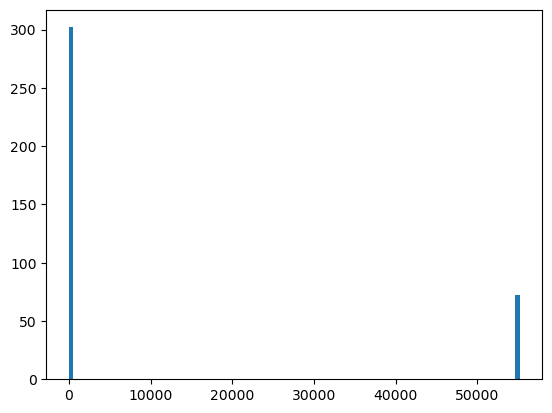

In [682]:
# plot the distribution of weights
plt.hist(weights, bins=100)

In [683]:
normailzed_weights = np.asarray(weights) / np.sum(weights)

quantiles = weighted_quantile(scores, alpha, normailzed_weights)
print("CP-PPI: Interval: (" + str(first_term_mean_s0 + quantiles[0]) + ", " + str((first_term_mean_s0 + quantiles[1])) + ")")

CP-PPI: Interval: (0.9766332245229672, 1.011991437136148)


In [541]:
print("v(pi_e) full policy = " + str(np.mean(target_trajectories_o['reward_sum']))) # Considering only the first 100 behavior trajectories.
print("v_pie(s_0) = " + str(behavior_trajectories_o['reward_sum'][0])) # This is the true value

v(pi_e) full policy = 0.7457627118644068
v_pie(s_0) = 1


In [684]:
first_term_mean_s0

np.float64(0.6894448774548587)